<a href="https://colab.research.google.com/github/SaadOjo/Circle-Detection/blob/main/Circle_Detection_and_Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2

In [2]:
def add_square(img, center, width):
  start_point = (center[0]-width, center[1]-width)
  end_point   = (center[0]+width, center[1]+width)
  cv2.rectangle(img, start_point, end_point, random_color(),cv2.FILLED)

In [3]:
def create_data_sample(num_shapes, height, width):
  img = np.zeros((height, width, 3))
  label = np.zeros((height, width, 1))
  for _ in range(num_shapes):
    x = int(np.random.rand()*width)
    y = int(np.random.rand()*height)
    if np.random.rand() > 0.5:
      cv2.circle(img, (x,y), int(np.ceil(width*0.05)), random_color(), cv2.FILLED)
      cv2.circle(label, (x,y), int(np.ceil(width*0.02)), (1,1,1), cv2.FILLED)
    else: 
      add_square(img, (x,y), int(np.ceil(width*0.05*0.7)))
  return img, label


In [4]:
def test_batch(num_shapes, height, width):
  img, label = create_data_sample(num_shapes, height, width)
  return np.expand_dims(img,0), np.expand_dims(label,0)

In [5]:
def grayscale_image(img):
  return np.expand_dims((img[:,:,0] + img[:,:,1] + img[:,:,2])/3,2)

In [6]:
# (128,128,1) --> (128,128,3)
def to_three_channels(img):
  return np.squeeze(np.stack((img,img,img), 2))

In [7]:
def random_color():
  return np.random.rand(3)

In [8]:
def show_sample(img, label):
  figure, axis = plt.subplots(1,2)
  axis[0].imshow(img)
  axis[1].imshow(to_three_channels(label))

In [9]:
def show_batch(img, label):
  show_sample(img[0,:,:,:],label[0,:,:,:])

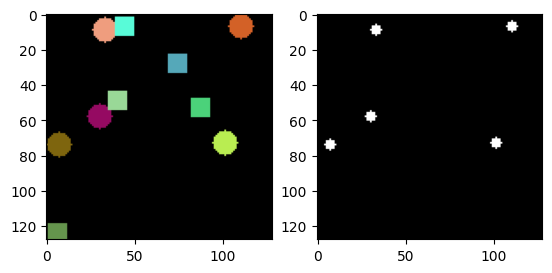

In [10]:
img_shape = (128,128,3)
img, label = create_data_sample(10, img_shape[0], img_shape[1])
show_sample(img, label)

(1, 128, 128, 3) (1, 128, 128, 1)


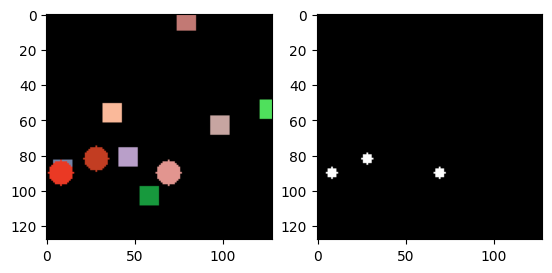

In [11]:
img, label = test_batch(10, img_shape[0], img_shape[1])
print(img.shape, label.shape)
show_batch(img, label)

In [12]:
#l2 = keras.regularizers.l2(1e-5)
l2 = None
inputs = keras.Input(shape=img_shape)
conv1 = keras.layers.Conv2D(16,5,padding='same',activation='relu',kernel_initializer='glorot_normal',kernel_regularizer=l2)(inputs)
conv1 = keras.layers.BatchNormalization(momentum=0.99)(conv1)
conv2 = keras.layers.Conv2D(32,5,padding='same',activation='relu',kernel_initializer='glorot_normal',kernel_regularizer=l2)(conv1)
conv2 = keras.layers.BatchNormalization(momentum=0.99)(conv2)
outputs = keras.layers.Conv2D(1,5,padding='same',activation='relu',kernel_initializer='glorot_normal',kernel_regularizer=l2)(conv2)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 1)    │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,041 (58.75 KB)

 Trainable params: 14,945 (58.38 KB)

 Non-trainable params: 96 (384.00 B)

In [13]:
def loss_function(y_true, y_pred):
  squared_diff = tf.square(y_true - y_pred)
  return tf.reduce_mean(squared_diff)


In [14]:
x_list = []
y_list = []
for i in range(1000):
  x,y  = create_data_sample(10, img_shape[0], img_shape[1])
  x_list.append(x)
  y_list.append(y)
x_list = np.array(x_list)
y_list = np.array(y_list)

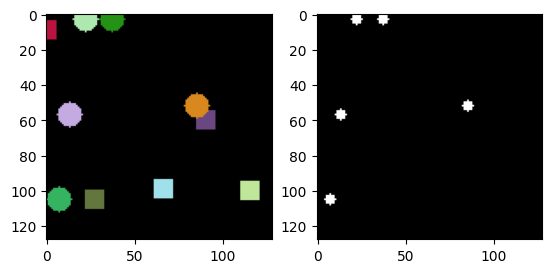

In [15]:
i = 3
show_sample(x_list[i], y_list[i])

In [16]:
x_list.shape

(1000, 128, 128, 3)

In [17]:
opt = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=opt,loss=loss_function)

In [18]:

model.fit(x_list,y_list,batch_size=100,epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 677ms/step - loss: 0.6974
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 669ms/step - loss: 0.2710
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 664ms/step - loss: 0.1969
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 685ms/step - loss: 0.1455
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 687ms/step - loss: 0.1148
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 680ms/step - loss: 0.0947
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 688ms/step - loss: 0.0802
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 698ms/step - loss: 0.0687
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 712ms/step - loss: 0.0599
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 689ms/step - loss: 0.0521
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 699ms/step - loss: 0.0455
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 682ms/step - loss: 0.0403
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 652ms/step - loss: 0.0363
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 661ms/step - loss: 0.0327
Epoch 15/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 

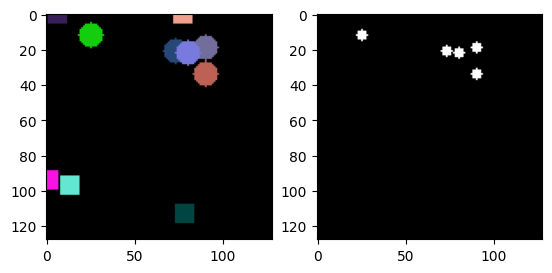

In [19]:
img, label = test_batch(10, img_shape[0], img_shape[1])
show_batch(img,label)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1.5814799


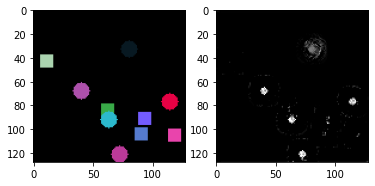

In [ ]:
y_pred = model.predict(img)
print(y_pred.max())
show_batch(img, y_pred)

In [ ]:
loss_function(y_pred, label)

<tf.Tensor: shape=(1, 128, 128), dtype=float64, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])>